In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

target = "Survived"

numeric = df.select_dtypes(include="number").columns.drop(target).tolist()
categorical = df.select_dtypes(exclude="number").columns.tolist()

print("Числовые:", numeric)
print("Категориальные:", categorical)
print("Целевой:", target)

Числовые: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Категориальные: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Целевой: Survived


In [2]:
print(df.isna().sum())
print(df.describe())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  


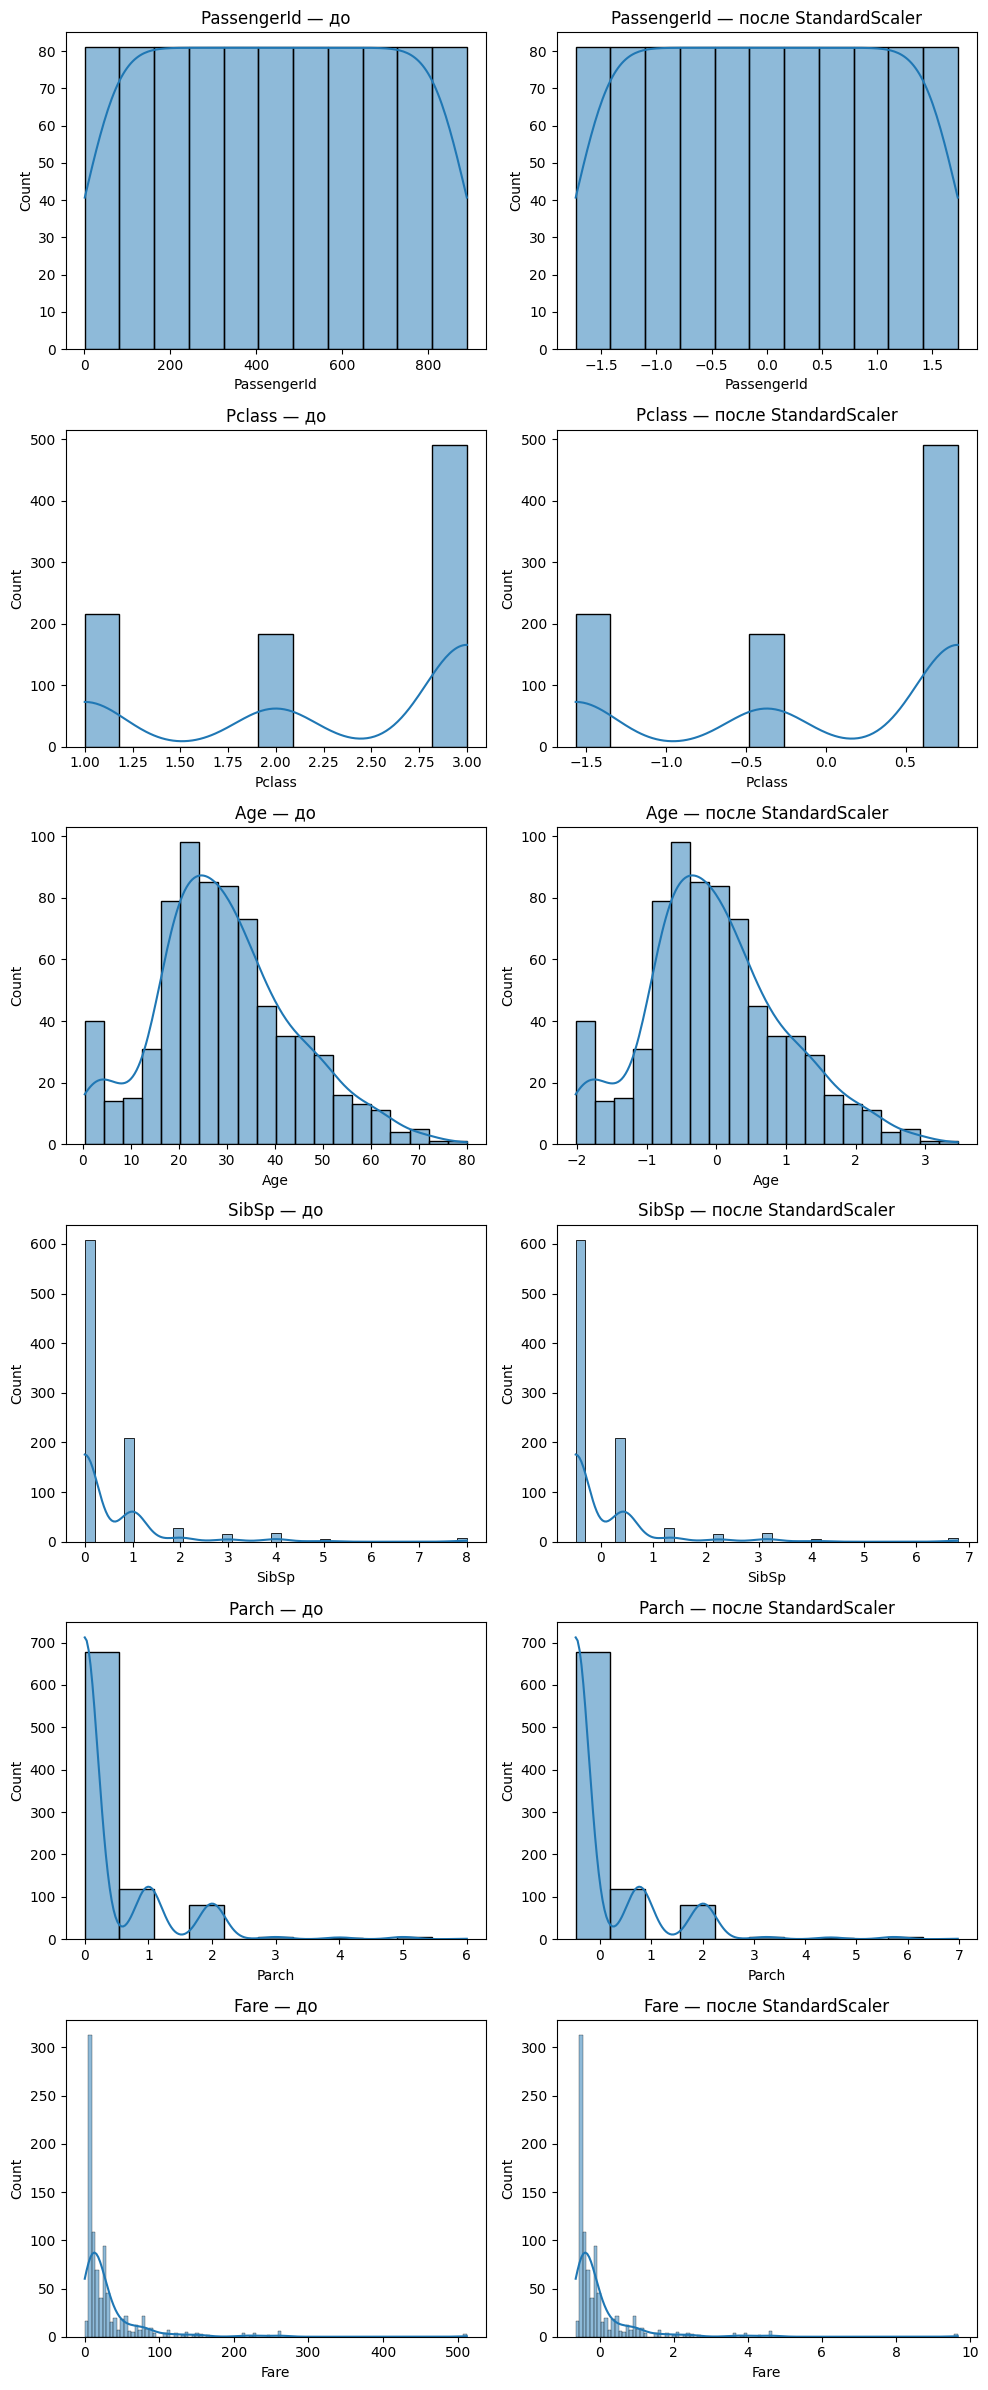

In [3]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()

df_standard = df.copy()
df_standard[numeric] = scaler.fit_transform(df[numeric])

fig, axes = plt.subplots(len(numeric), 2, figsize=(10, 4 * len(numeric)))

for i, col in enumerate(numeric):
    sns.histplot(df[col], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"{col} — до")

    sns.histplot(df_standard[col], ax=axes[i, 1], kde=True)
    axes[i, 1].set_title(f"{col} — после StandardScaler")

plt.tight_layout()
plt.show()

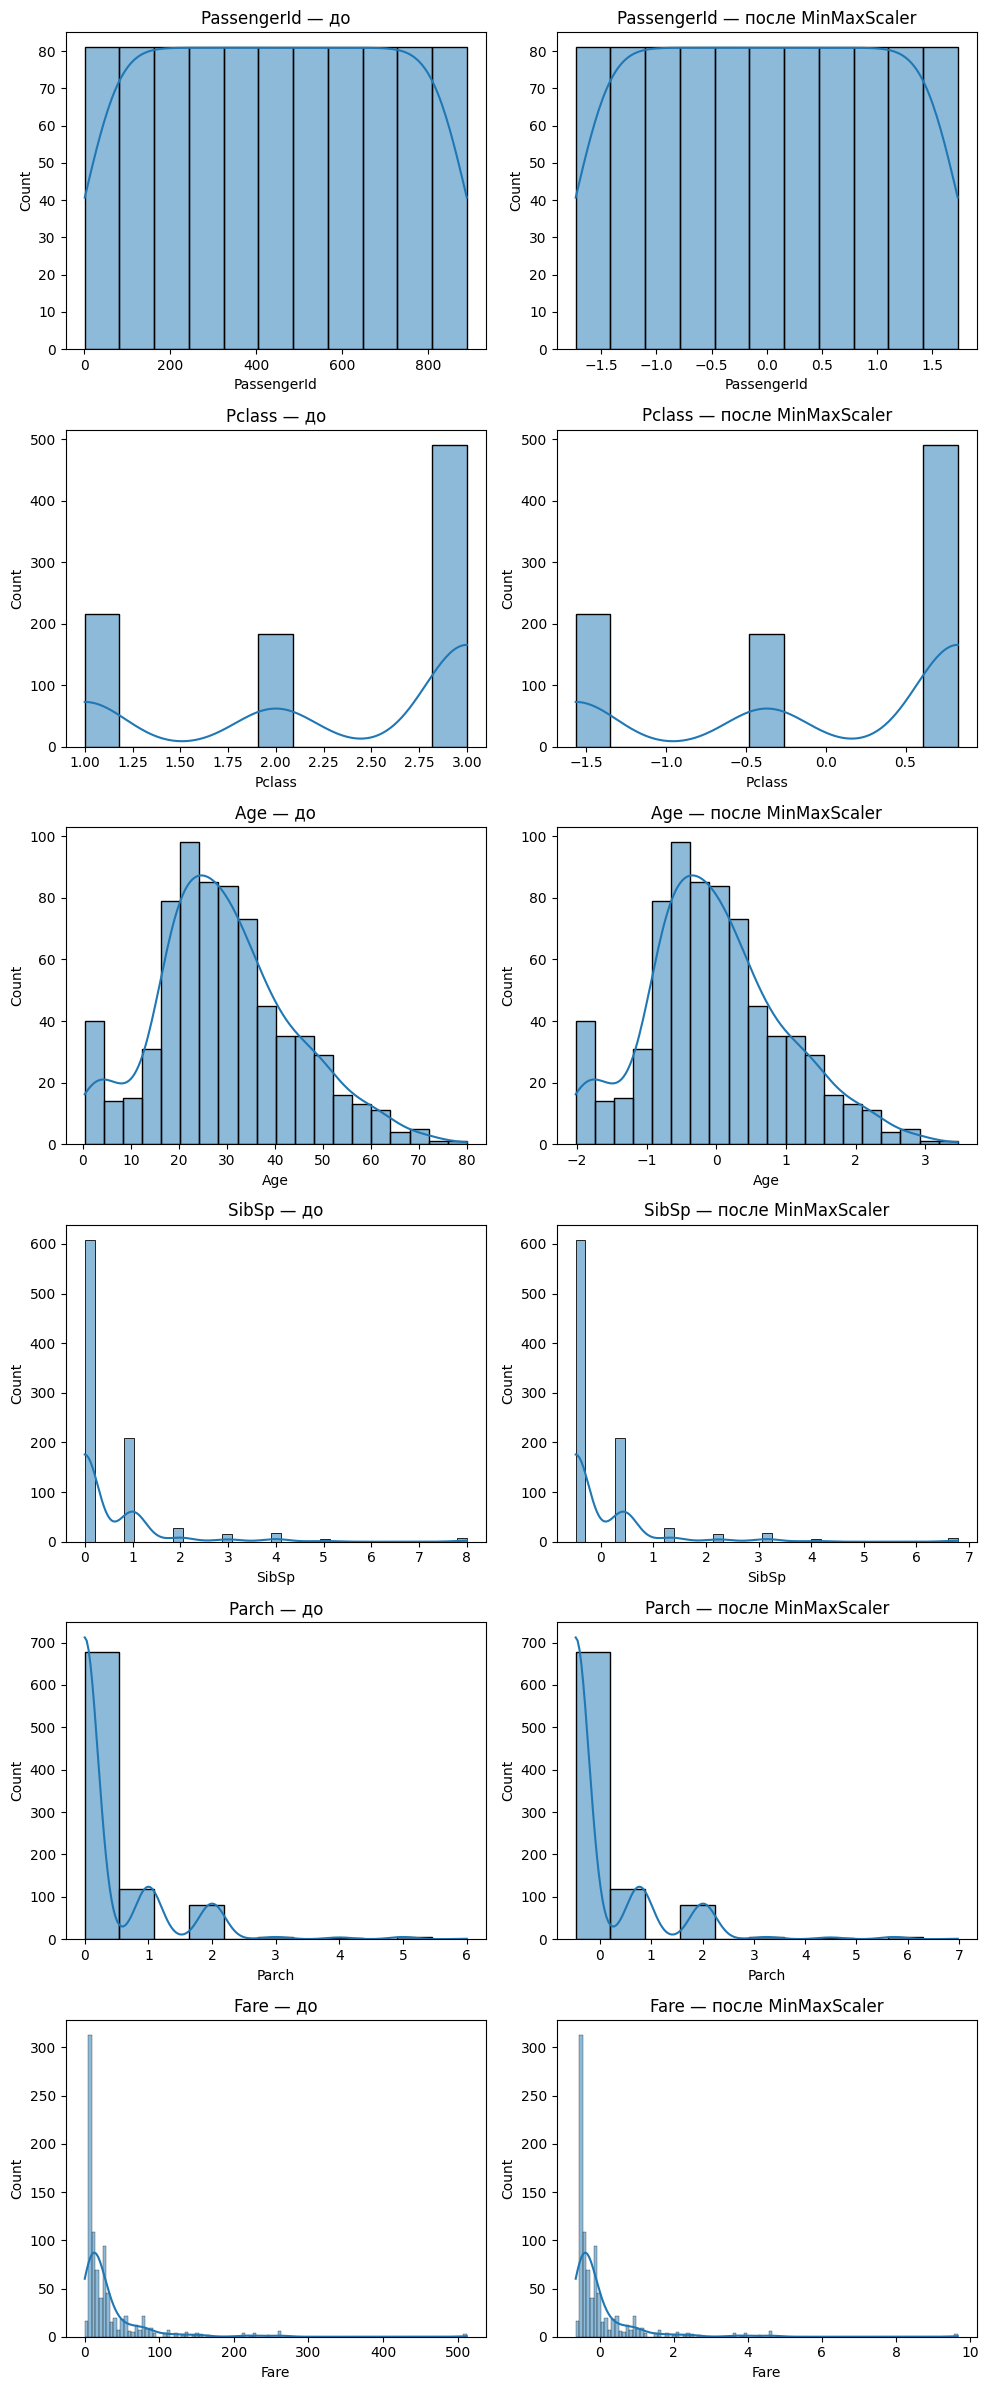

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numeric] = scaler.fit_transform(df[numeric])

fig, axes = plt.subplots(len(numeric), 2, figsize=(10, 4 * len(numeric)))

for i, col in enumerate(numeric):
    sns.histplot(df[col], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"{col} — до")

    sns.histplot(df_standard[col], ax=axes[i, 1], kde=True)
    axes[i, 1].set_title(f"{col} — после MinMaxScaler")

plt.tight_layout()
plt.show()

Масштабирование нужно, когда модель чувствительна к масштабу признаков: например, KNN, SVM, K-Means, PCA и нейросети.

Для деревьев решений и Random Forest обычно не требуется.

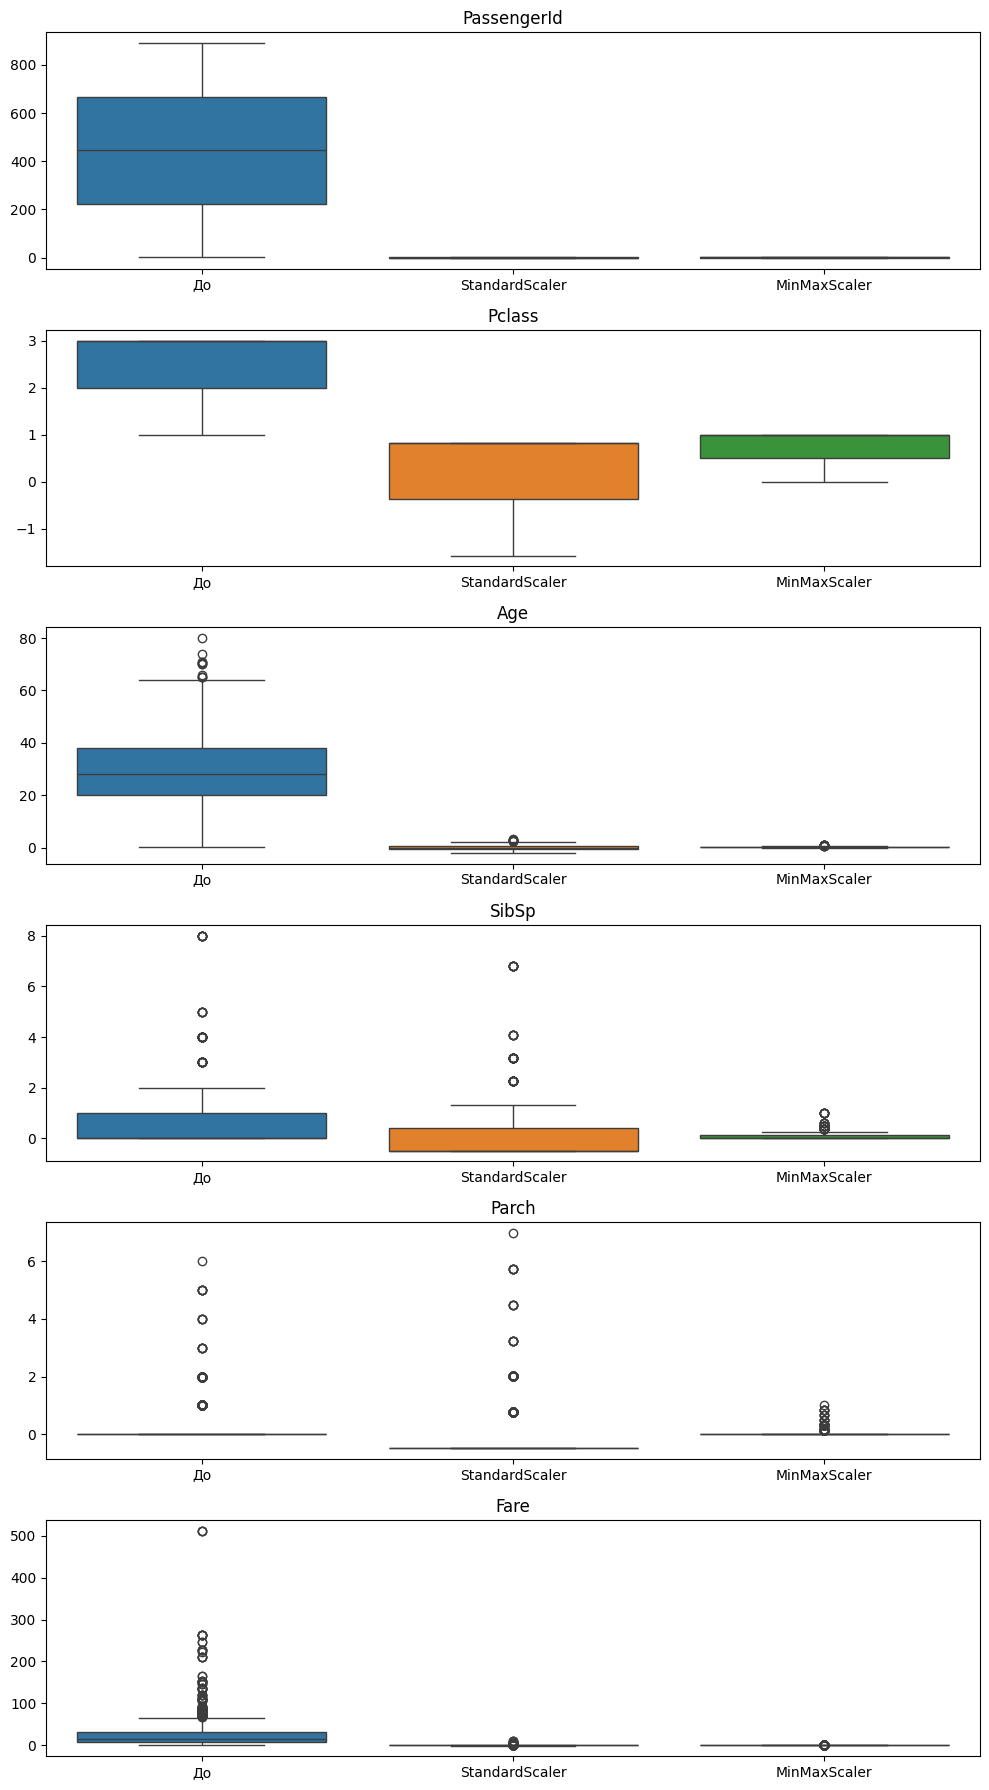

In [5]:
fig, axes = plt.subplots(len(numeric), 1, figsize=(10, 3 * len(numeric)))

for i, col in enumerate(numeric):
    comparison = pd.DataFrame({
        "До": df[col],
        "StandardScaler": df_standard[col],
        "MinMaxScaler": df_minmax[col]
    })

    sns.boxplot(data=comparison, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()